# Too Hot to Handle — Figures and Captions

This notebook generates the main-text figures for the paper from existing project artifacts and stores draft captions alongside them.

The main-text figure set is deliberately narrow:

1. Model and data pipeline
2. Validation against annual and intraday benchmarks
3. Scenario tradeoff plot
4. Financial impact by income quintile
5. Spatial concentration of benefits

## Note on current validation artifacts

The calibration output currently available in the repo covers **2021–2023**, not 2020–2023. The draft text should be corrected to match the artifact unless the 2020 comparison is regenerated.


In [15]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.lines import Line2D

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OUTDIR = ROOT / 'notebooks' / 'results' / 'too_hot_to_handle_figures'
OUTDIR.mkdir(parents=True, exist_ok=True)

# Auto-detect the most recent calibration_<timestamp> directory.
_cal_dirs = sorted((ROOT / 'results').glob('calibration_*'), key=lambda p: p.name)
if not _cal_dirs:
    raise FileNotFoundError(f"No calibration_* directory under {ROOT / 'results'}")
CAL_DIR = _cal_dirs[-1]
print(f'Using calibration run: {CAL_DIR.name}')

CITY_VALIDATION_CSV = CAL_DIR / 'desnz_city_comparison.csv'
CAL_SEG_TS_CSV      = CAL_DIR / 'calibrated_segmentation_timeseries.csv'
SERL_PROFILES_CSV   = ROOT / 'data'    / 'serl_profiles' / 'serl_profiles_num_occupants.csv'
SCENARIO_SUMMARY_CSV = ROOT / 'notebooks' / 'results' / 'scenario_summary' / 'scenario_summary.csv'
SCENARIO_LONG_CSV    = ROOT / 'notebooks' / 'results' / 'scenario_summary' / 'scenario_map_long.csv'
HP_AUDIT_CSV         = ROOT / 'notebooks' / 'results' / 'scenario_v2_1'   / 'hp_adoption_impact_audit.csv'
GEOJSON             = ROOT / 'data' / 'epc_abm_newcastle.geojson'

for p in [CITY_VALIDATION_CSV, CAL_SEG_TS_CSV, SERL_PROFILES_CSV,
          SCENARIO_SUMMARY_CSV, SCENARIO_LONG_CSV, HP_AUDIT_CSV, GEOJSON]:
    if not p.exists():
        raise FileNotFoundError(p)

# ── Shared aesthetic ──────────────────────────────────────────────────────────
# Vega-Lite palette used consistently across all figures
BLUE   = '#4c78a8'   # ABM / model
ORANGE = '#f58518'   # DESNZ / reference data
RED    = '#e45756'   # heat pump scenarios / alerts
GREEN  = '#54a24b'   # within target
TEAL   = '#72b7b2'   # supplementary comparisons
YELLOW = '#f2cf5b'   # marginal tolerance
GRAY_L = '#e8e8e8'   # shaded envelopes
GRAY_M = '#9e9e9e'   # reference lines / faint elements

SCENARIO_COLORS  = {'hp_top_users': BLUE,  'hp_social_rent': RED}
SCENARIO_LABELS  = {'hp_top_users': 'Top-user HPs', 'hp_social_rent': 'Social-rent HPs'}
QUINTILE_ORDER   = ['q1_lowest', 'q2_low', 'q3_mid', 'q4_high', 'q5_highest']
QUINTILE_LABELS  = {'q1_lowest': 'Q1\n(lowest)', 'q2_low': 'Q2', 'q3_mid': 'Q3',
                    'q4_high': 'Q4', 'q5_highest': 'Q5\n(highest)'}

plt.rcParams.update({
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.spines.left':      True,
    'axes.spines.bottom':    True,
    'axes.grid':             True,
    'grid.color':            '#e0e0e0',
    'grid.linewidth':        0.7,
    'axes.titleweight':      'bold',
    'axes.titlesize':        12,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       9,
    'legend.framealpha':     0.9,
    'legend.edgecolor':      '#cccccc',
    'figure.dpi':            100,
    'savefig.dpi':           200,
    'savefig.bbox':          'tight',
})

print(f'Root:       {ROOT}')
print(f'Output dir: {OUTDIR}')
print('All input files found.')


Root:       /Users/abeltran/Documents/GitHub/spdt_abm
Output dir: /Users/abeltran/Documents/GitHub/spdt_abm/notebooks/results/too_hot_to_handle_figures
All input files found.


In [16]:
# Compatibility helpers for revised policy_scenarios_summary.ipynb outputs.
# Prefer effective-adopter fields in scenario_summary.csv; fall back to the legacy audit file.
SCENARIO_UPTAKE_RATES = {'hp_social_rent': 0.50, 'hp_top_users': 0.20}

def load_hp_scenario_effects(scenarios, tariff=0.24):
    summary = pd.read_csv(SCENARIO_SUMMARY_CSV)
    new_cols = {
        'effective_adopters', 'mean_saving_effective_kwh_year',
        'p10_saving_effective_kwh_year', 'p90_saving_effective_kwh_year',
        'total_saving_kwh_year', 'total_bill_saving_gbp_24p',
    }
    if new_cols.issubset(summary.columns):
        df = summary[summary['scenario'].isin(scenarios)].copy()
        df['n_treated'] = df['effective_adopters'].astype(int)
        df['mean_kwh'] = df['mean_saving_effective_kwh_year'].astype(float)
        df['p10_kwh'] = df['p10_saving_effective_kwh_year'].astype(float)
        df['p90_kwh'] = df['p90_saving_effective_kwh_year'].astype(float)
        df['total_kwh'] = df['total_saving_kwh_year'].astype(float)
        df['total_gbp'] = df['total_bill_saving_gbp_24p'].astype(float)
        df['uptake_rate'] = df.get('uptake_rate', df['scenario'].map(SCENARIO_UPTAKE_RATES)).astype(float)
        source = 'scenario_summary.csv effective-adopter fields'
    else:
        audit = pd.read_csv(HP_AUDIT_CSV)
        df = audit[(audit['scope'] == 'treated_cohort') & audit['scenario'].isin(scenarios)].copy()
        df['n_treated'] = df['n_homes'].astype(int)
        df['mean_kwh'] = -df['mean_delta_kwh_year'].astype(float)
        df['p10_kwh'] = -df['p90_delta_kwh_year'].astype(float)
        df['p90_kwh'] = -df['p10_delta_kwh_year'].astype(float)
        df['total_kwh'] = -df['delta_total_kwh_year'].astype(float)
        df['total_gbp'] = df['total_kwh'] * tariff
        df['uptake_rate'] = df['scenario'].map(SCENARIO_UPTAKE_RATES).astype(float)
        source = 'legacy hp_adoption_impact_audit.csv treated_cohort rows'

    df['label'] = df['scenario'].map({
        'hp_top_users': 'Top-user HPs',
        'hp_social_rent': 'Social-rent HPs',
            }).fillna(df['scenario'])
    df['color'] = df['scenario'].map({
        'hp_top_users': BLUE,
        'hp_social_rent': RED,
            }).fillna(GRAY_M)
    df['mean_gbp'] = df['mean_kwh'] * tariff
    df['p10_gbp'] = df['p10_kwh'] * tariff
    df['p90_gbp'] = df['p90_kwh'] * tariff
    df.attrs['source'] = source
    missing = set(scenarios) - set(df['scenario'])
    if missing:
        raise ValueError(f'Missing HP scenario outputs for: {sorted(missing)}')
    return df


## Figure 1. Model and data pipeline

**Draft caption.**

*Figure 1. Structure of the Household Energy MABM and its empirical data pipeline. Energy Performance Certificate records provide dwelling-level physical attributes; Census 2021 marginals and Understanding Society microdata are combined to construct a synthetic household population matched to dwellings via UPRN; ERA5 reanalysis provides hourly outdoor temperatures; SERL smart meter statistics are used for analytical calibration; and DESNZ sub-national consumption statistics provide independent validation. The integrated model simulates hourly residential energy demand at dwelling resolution and produces policy-relevant outputs including annual demand totals, scenario tradeoffs, bill-saving estimates, and spatial distributions of benefits.*


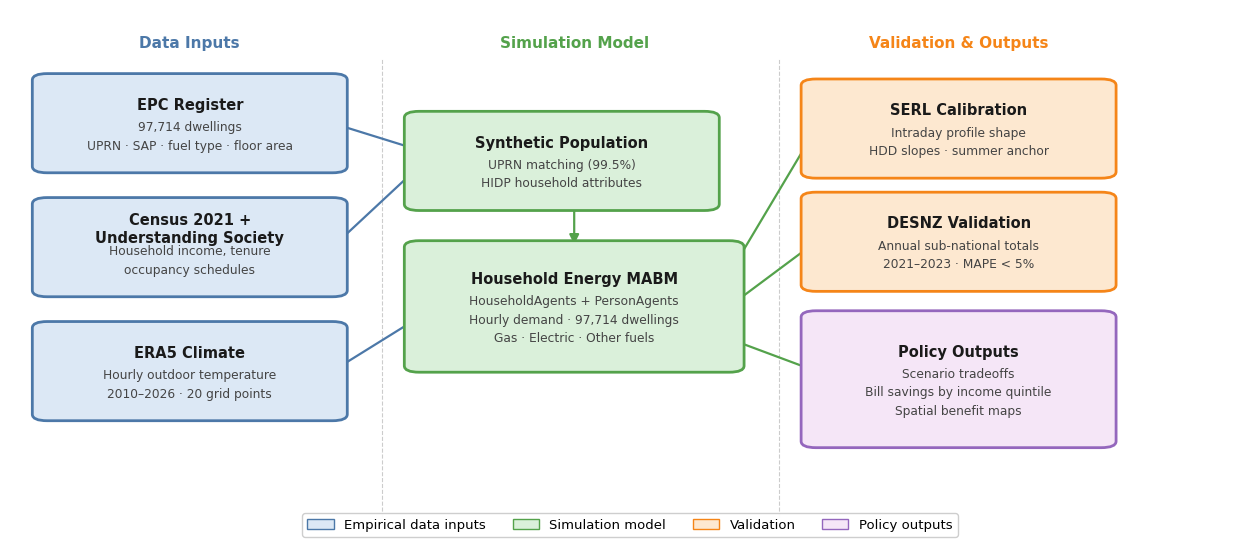

Figure 1 saved.


In [17]:
# ── Figure 1. Model and data pipeline ─────────────────────────────────────────
# Three-column layout: Data Inputs → Model Core → Validation & Outputs
# All arrows originate from the MABM box (right edge) into the correct target.

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# ── Color scheme by functional role ──────────────────────────────────────────
FILL = {'data': '#dce8f5', 'model': '#daf0da', 'validate': '#fde8d0', 'output': '#f5e6f7'}
EDGE = {'data': '#4c78a8',  'model': '#54a24b',  'validate': '#f58518',  'output': '#9467bd'}

LINE_H = 0.030   # approx vertical space per text line in fig coords

def box(x, y, w, h, title, subtitle='', role='data'):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.012,rounding_size=0.012',
        fc=FILL[role], ec=EDGE[role], lw=2.0, zorder=3,
    ))
    cx = x + w / 2
    cy = y + h / 2
    if subtitle:
        n_sub = subtitle.count('\n') + 1
        # push title above centre, subtitle below
        title_y = cy + n_sub * LINE_H * 0.55
        sub_y   = cy - LINE_H * 0.85
        ax.text(cx, title_y, title, ha='center', va='center',
                fontsize=10.5, fontweight='bold', color='#1a1a1a', zorder=4)
        ax.text(cx, sub_y, subtitle, ha='center', va='center',
                fontsize=8.8, color='#444', zorder=4, linespacing=1.55)
    else:
        ax.text(cx, cy, title, ha='center', va='center',
                fontsize=10.5, fontweight='bold', color='#1a1a1a', zorder=4)

def arr(x0, y0, x1, y1, rad=0.0, color='#555'):
    ax.annotate(
        '', xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle='-|>', color=color, lw=1.6,
            mutation_scale=14,
            connectionstyle=f'arc3,rad={rad}',
        ),
        zorder=2,
    )

# ── Box geometry ──────────────────────────────────────────────────────────────
# Col 1 — data inputs (x=0.03)
box(0.03, 0.71, 0.23, 0.16, 'EPC Register',
    '97,714 dwellings\nUPRN · SAP · fuel type · floor area', role='data')
box(0.03, 0.48, 0.23, 0.16, 'Census 2021 +\nUnderstanding Society',
    'Household income, tenure\noccupancy schedules', role='data')
box(0.03, 0.25, 0.23, 0.16, 'ERA5 Climate',
    'Hourly outdoor temperature\n2010–2026 · 20 grid points', role='data')

# Column header
ax.text(0.145, 0.93, 'Data Inputs', ha='center', fontsize=11, fontweight='bold',
        color=EDGE['data'])
ax.axvline(0.30, 0.06, 0.91, color='#ccc', lw=0.8, ls='--', zorder=1)

# Col 2 — model core (x=0.33)
# MABM box: right edge = 0.33 + 0.25 = 0.58
MABM_L = 0.33;  MABM_W = 0.25
MABM_B = 0.34;  MABM_H = 0.22
box(0.33, 0.64, 0.23, 0.16, 'Synthetic Population',
    'UPRN matching (99.5%)\nHIDP household attributes', role='model')
box(MABM_L, MABM_B, MABM_W, MABM_H, 'Household Energy MABM',
    'HouseholdAgents + PersonAgents\nHourly demand · 97,714 dwellings\nGas · Electric · Other fuels',
    role='model')

ax.text(0.455, 0.93, 'Simulation Model', ha='center', fontsize=11, fontweight='bold',
        color=EDGE['model'])
ax.axvline(0.62, 0.06, 0.91, color='#ccc', lw=0.8, ls='--', zorder=1)

# Col 3 — validation & outputs (x=0.65)
box(0.65, 0.70, 0.23, 0.16, 'SERL Calibration',
    'Intraday profile shape\nHDD slopes · summer anchor', role='validate')
box(0.65, 0.49, 0.23, 0.16, 'DESNZ Validation',
    'Annual sub-national totals\n2021–2023 · MAPE < 5%', role='validate')
box(0.65, 0.20, 0.23, 0.23, 'Policy Outputs',
    'Scenario tradeoffs\nBill savings by income quintile\nSpatial benefit maps', role='output')

ax.text(0.765, 0.93, 'Validation & Outputs', ha='center', fontsize=11, fontweight='bold',
        color=EDGE['validate'])

# ── Arrows ────────────────────────────────────────────────────────────────────
MABM_R  = MABM_L + MABM_W      # right edge of MABM box = 0.58
MABM_CY = MABM_B + MABM_H / 2  # vertical centre of MABM box

# Data → synthetic population
arr(0.26, 0.79, 0.33, 0.74, color=EDGE['data'])
arr(0.26, 0.56, 0.33, 0.71, color=EDGE['data'])
# ERA5 → MABM (left edge)
arr(0.26, 0.33, MABM_L, 0.43, color=EDGE['data'])
# Synthetic pop → MABM (top edge)
arr(0.455, 0.64, 0.455, MABM_B + MABM_H, color=EDGE['model'])
# MABM → SERL calibration
arr(MABM_R, MABM_CY + 0.06, 0.65, 0.78, color=EDGE['model'])
# MABM → DESNZ validation
arr(MABM_R, MABM_CY,        0.65, 0.57, color=EDGE['model'])
# MABM → policy outputs
arr(MABM_R, MABM_CY - 0.06, 0.65, 0.33, color=EDGE['model'])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(fc=FILL['data'],     ec=EDGE['data'],     label='Empirical data inputs'),
    mpatches.Patch(fc=FILL['model'],    ec=EDGE['model'],    label='Simulation model'),
    mpatches.Patch(fc=FILL['validate'], ec=EDGE['validate'], label='Validation'),
    mpatches.Patch(fc=FILL['output'],   ec=EDGE['output'],   label='Policy outputs'),
]
ax.legend(handles=legend_items, loc='lower center', ncol=4,
          fontsize=9.5, framealpha=0.95, edgecolor='#ccc',
          bbox_to_anchor=(0.5, 0.01))

fig.savefig(OUTDIR / 'figure_1_pipeline.png')
plt.show()
print('Figure 1 saved.')


## Figure 2. Validation against annual and intraday benchmarks

**Draft caption.**

*Figure 2. Validation of the Household Energy MABM against annual and intraday benchmarks. Panel A compares modelled annual residential energy demand in Newcastle upon Tyne with DESNZ sub-national consumption statistics for 2021–2023, showing that the model reproduces inter-annual variation with low error and a slight conservative bias. Panels B–D compare modelled intraday demand profiles with SERL-derived hourly envelopes, showing that the model reproduces the timing of the morning peak, evening peak, and overnight trough. Together, these checks indicate that the model captures both the annual scale and the within-day structure of household demand.*


 year    ratio  abs_pct_error  signed_pct_error
 2021 0.904067       9.593311         -9.593311
 2022 0.961873       3.812732         -3.812732
 2023 0.960074       3.992592         -3.992592


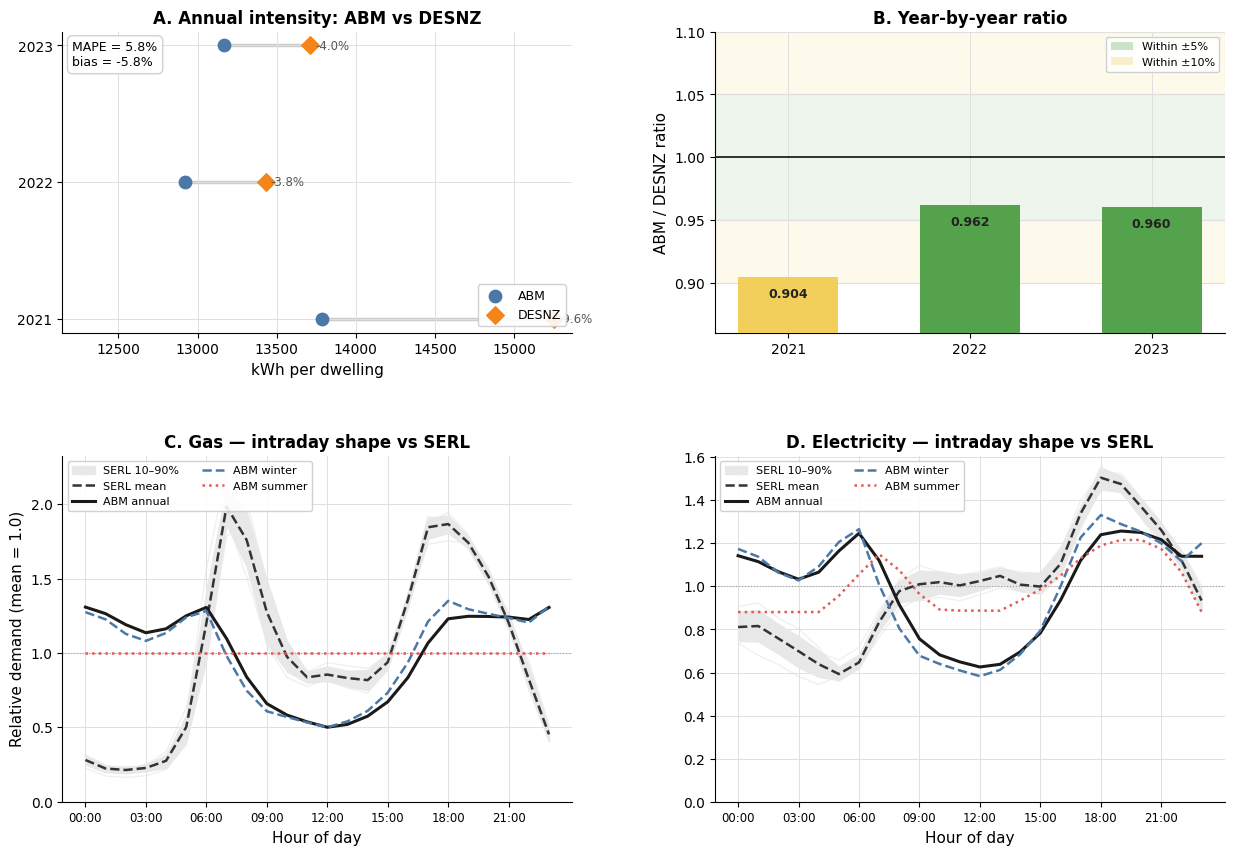

Figure 2 saved.


In [18]:
# ── Figure 2. Validation against annual and intraday benchmarks ───────────────
# Layout: 2-row × 2-col
#   Top-left  A: dumbbell (ABM vs DESNZ kWh/dwelling) + MAPE annotation
#   Top-right B: ABM/DESNZ ratio bars with tolerance bands and residual labels
#   Bottom    C & D: intraday gas / electric profiles vs SERL 10–90% envelope

# ── Load and prepare data ─────────────────────────────────────────────────────
city = pd.read_csv(CITY_VALIDATION_CSV).sort_values('year').copy()
city['abs_pct_error']    = (city['ratio'] - 1.0).abs() * 100.0
city['signed_pct_error'] = (city['ratio'] - 1.0) * 100.0
mape = city['abs_pct_error'].mean()
bias = city['signed_pct_error'].mean()

seg  = pd.read_csv(CAL_SEG_TS_CSV)
prof = pd.read_csv(SERL_PROFILES_CSV)

seg['timestamp_utc'] = pd.to_datetime(seg['timestamp_utc'], utc=True, errors='coerce')
seg = seg[seg['segmentation'].astype(str) == 'central_heating_type'].copy()
seg['value_l']   = seg['value'].astype(str).str.lower()
seg['month_loc'] = seg['timestamp_utc'].dt.tz_convert('Europe/London').dt.month
seg['hour_loc']  = seg['timestamp_utc'].dt.tz_convert('Europe/London').dt.hour

seg_gas  = seg[seg['value_l'].str.contains('gas', na=False)].copy()
seg_elec = seg[~seg['value_l'].str.contains('gas', na=False) & ~seg['value_l'].eq('no data')].copy()

def abm_norm_profile(df, kwh_col, months):
    sub = df[df['month_loc'].isin(months)].copy()
    agg = sub.groupby('hour_loc', as_index=False).agg(
        total_kwh=(kwh_col, 'sum'), n=('n_homes', 'sum'))
    agg['kwh_per_home'] = agg['total_kwh'] / agg['n'].replace({0: np.nan})
    mu = agg['kwh_per_home'].mean()
    agg['mult'] = agg['kwh_per_home'] / mu if pd.notna(mu) and mu != 0 else np.nan
    return agg.sort_values('hour_loc')

seasons = {'annual': list(range(1, 13)), 'winter': [12, 1, 2], 'summer': [6, 7, 8]}
abm = {}
for s, months in seasons.items():
    abm[('gas',     s)] = abm_norm_profile(seg_gas,  'gas_kwh',      months)
    abm[('electric', s)] = abm_norm_profile(seg_elec, 'electric_kwh', months)

prof = prof[(prof['kind'].astype(str) == 'hourly') & prof['fuel'].isin(['gas', 'electric'])].copy()

# ── Build figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.28, height_ratios=[1, 1.15])
ax_dumb  = fig.add_subplot(gs[0, 0])
ax_ratio = fig.add_subplot(gs[0, 1])
ax_gas   = fig.add_subplot(gs[1, 0])
ax_elec  = fig.add_subplot(gs[1, 1])

# ── Panel A: dumbbell ─────────────────────────────────────────────────────────
y = np.arange(len(city))
for i, row in city.reset_index(drop=True).iterrows():
    ax_dumb.plot([row['abm_kwh_per_dw'], row['desnz_kwh_per_dw']], [i, i],
                 color='#cccccc', lw=2.5, solid_capstyle='round', zorder=1)
ax_dumb.scatter(city['abm_kwh_per_dw'],   y, color=BLUE,   s=80, zorder=3, label='ABM',   clip_on=False)
ax_dumb.scatter(city['desnz_kwh_per_dw'], y, color=ORANGE, s=80, zorder=3, label='DESNZ', clip_on=False, marker='D')

# Annotate signed % error on each row
for i, row in city.reset_index(drop=True).iterrows():
    sign = '+' if row['signed_pct_error'] >= 0 else ''
    xpos = max(row['abm_kwh_per_dw'], row['desnz_kwh_per_dw']) + 30
    ax_dumb.text(xpos, i, f"{sign}{row['signed_pct_error']:.1f}%",
                 va='center', fontsize=8.5, color='#555')

ax_dumb.set_yticks(y)
ax_dumb.set_yticklabels(city['year'].astype(str), fontsize=10)
ax_dumb.set_xlabel('kWh per dwelling')
ax_dumb.set_title('A. Annual intensity: ABM vs DESNZ')
ax_dumb.legend(loc='lower right')
ax_dumb.set_xlim(left=city[['abm_kwh_per_dw', 'desnz_kwh_per_dw']].min().min() * 0.94)
# MAPE box
ax_dumb.text(0.02, 0.97, f'MAPE = {mape:.1f}%\nbias = {bias:+.1f}%',
             transform=ax_dumb.transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#ccc', alpha=0.9))

# ── Panel B: ratio bars with tolerance bands ──────────────────────────────────
bar_colors = [GREEN if 0.95 <= r <= 1.05 else YELLOW if 0.90 <= r <= 1.10 else RED
              for r in city['ratio']]
bars = ax_ratio.bar(city['year'].astype(str), city['ratio'], color=bar_colors,
                    width=0.55, zorder=3)
ax_ratio.axhspan(0.95, 1.05, color=GREEN, alpha=0.10, zorder=1, label='±5% band')
ax_ratio.axhspan(0.90, 0.95, color=YELLOW, alpha=0.12, zorder=1)
ax_ratio.axhspan(1.05, 1.10, color=YELLOW, alpha=0.12, zorder=1, label='±10% band')
ax_ratio.axhline(1.0, color='#222', lw=1.3, zorder=4)
ax_ratio.set_ylim(0.86, 1.10)
ax_ratio.set_ylabel('ABM / DESNZ ratio')
ax_ratio.set_title('B. Year-by-year ratio')

for b, r in zip(bars, city['ratio']):
    ax_ratio.text(b.get_x() + b.get_width() / 2,
                  b.get_height() + 0.004 if r >= 1 else b.get_height() - 0.008,
                  f'{r:.3f}', ha='center',
                  va='bottom' if r >= 1 else 'top',
                  fontsize=9, fontweight='bold', color='#222', zorder=5)

legend_items = [
    mpatches.Patch(fc=GREEN,  alpha=0.3, label='Within ±5%'),
    mpatches.Patch(fc=YELLOW, alpha=0.3, label='Within ±10%'),
]
ax_ratio.legend(handles=legend_items, loc='upper right', fontsize=8)

# ── Panels C & D: intraday profiles ──────────────────────────────────────────
season_styles = {
    'annual': dict(color='#1a1a1a', lw=2.2, ls='-',  label='ABM annual'),
    'winter': dict(color=BLUE,      lw=1.8, ls='--', label='ABM winter'),
    'summer': dict(color=RED,       lw=1.8, ls=':',  label='ABM summer'),
}

for ax, fuel, panel_label in [
    (ax_gas,  'gas',      'C. Gas — intraday shape vs SERL'),
    (ax_elec, 'electric', 'D. Electricity — intraday shape vs SERL'),
]:
    pf = prof[prof['fuel'] == fuel].copy()

    # SERL per-occupancy group (thin gray lines for context)
    for _, grp in pf.groupby('seg3_value'):
        g = grp.sort_values('idx')
        ax.plot(g['idx'], g['mult'], color=GRAY_L, lw=0.9, alpha=0.7, zorder=1)

    # SERL 10–90 envelope and mean
    lo   = pf.groupby('idx')['mult'].quantile(0.10)
    hi   = pf.groupby('idx')['mult'].quantile(0.90)
    mean = pf.groupby('idx')['mult'].mean()
    ax.fill_between(lo.index, lo.values, hi.values,
                    color=GRAY_L, alpha=1.0, zorder=2, label='SERL 10–90%')
    ax.plot(mean.index, mean.values,
            color='#333', lw=1.8, ls='--', zorder=3, label='SERL mean')

    # ABM seasonal overlays
    for season, style in season_styles.items():
        d = abm[(fuel, season)]
        ax.plot(d['hour_loc'], d['mult'], zorder=4, **style)

    ax.axhline(1.0, color=GRAY_M, lw=0.8, ls=':', zorder=2)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], fontsize=8.5)
    ax.set_xlabel('Hour of day')
    ax.set_title(panel_label)
    ax.set_ylim(bottom=0)
    if ax is ax_gas:
        ax.set_ylabel('Relative demand (mean = 1.0)')
        ax.legend(loc='upper left', ncol=2, fontsize=8)
    else:
        ax.legend(loc='upper left', ncol=2, fontsize=8)

fig.savefig(OUTDIR / 'figure_2_validation.png')
print(city[['year', 'ratio', 'abs_pct_error', 'signed_pct_error']].to_string(index=False))
plt.show()
print('Figure 2 saved.')


## Figure 3. Scenario tradeoff plot

**Draft caption.**

*Figure 3. Heat-pump targeting tradeoff: social-rent scale versus top-user payoff. Panel A shows aggregate annual energy savings at city level — the top-user scheme delivers approximately twice the MWh reduction (29,490 MWh/yr, £7.1m/yr) despite treating only 2,714 dwellings, versus 14,327 MWh/yr (£3.4m/yr) for 4,836 social-rent households. Panel B shows the per-household payoff: top-user adopters save a mean of ≈£2,600/yr while social-rent adopters save ≈£700/yr, reflecting the energy-intensity criterion used for top-user selection. Together the panels show that targeting logic shapes both the scale and the distribution of programme benefits.*


Figure 3 data source: scenario_summary.csv effective-adopter fields


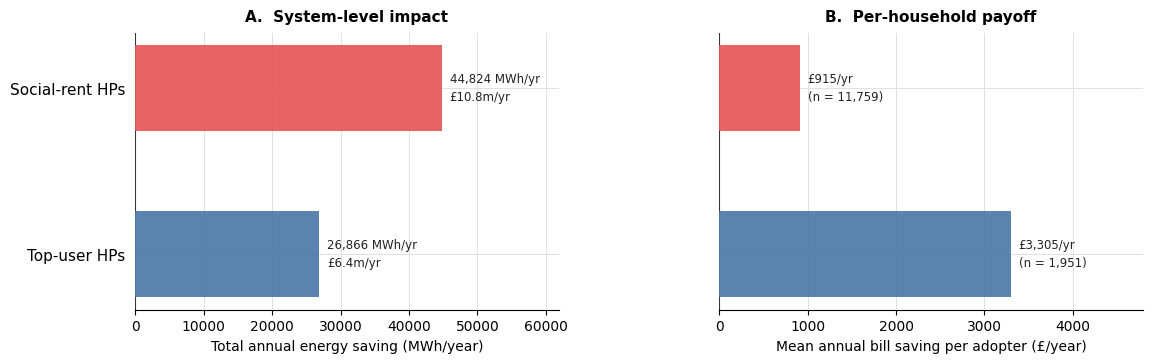

Figure 3 saved.


,scenario,n_treated,mean_kwh,mean_gbp,total_kwh,total_gbp
0,hp_social_rent,11759,3811.865208,914.847650,4.482372e+07,1.075769e+07
1,hp_top_users,1951,13770.488547,3304.917251,2.686622e+07,6.447894e+06


In [19]:
# ── Figure 3. Heat-pump targeting tradeoff ─────────────────────────────────────
# Panel A: aggregate system-level saving (MWh/yr, annotated with £m/yr)
# Panel B: mean annual saving per effective adopter (£/yr, annotated with n=)

HP_SCENS = ['hp_social_rent', 'hp_top_users']
TARIFF   = 0.24

plot_df = load_hp_scenario_effects(HP_SCENS, tariff=TARIFF)
# order: social-rent on top, top-users on bottom (matches reading order of labels)
plot_df = plot_df.set_index('scenario').reindex(HP_SCENS).reset_index()
print(f"Figure 3 data source: {plot_df.attrs.get('source')}")

LABELS   = [SCENARIO_LABELS[s] for s in plot_df['scenario']]
COLORS   = [SCENARIO_COLORS[s] for s in plot_df['scenario']]
y        = np.arange(len(plot_df))
BAR_H    = 0.52

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 3.6),
                                  gridspec_kw={'wspace': 0.38})

# ── Panel A: aggregate saving (MWh/yr) ───────────────────────────────────────
total_mwh = plot_df['total_kwh'] / 1e3
total_gbpm = plot_df['total_kwh'] * TARIFF / 1e6

ax_a.barh(y, total_mwh, height=BAR_H, color=COLORS, zorder=3, alpha=0.92)
ax_a.set_yticks(y)
ax_a.set_yticklabels(LABELS, fontsize=11)
ax_a.set_xlabel('Total annual energy saving (MWh/year)', fontsize=10)
ax_a.set_title('A.  System-level impact', fontsize=11, fontweight='bold', pad=8)
ax_a.set_xlim(0, total_mwh.max() * 1.38)
ax_a.axvline(0, color='#333', lw=0.8)
ax_a.invert_yaxis()

for i, (mwh, gbpm) in enumerate(zip(total_mwh, total_gbpm)):
    ax_a.text(mwh + total_mwh.max() * 0.025, i,
              f'{mwh:,.0f} MWh/yr\n£{gbpm:.1f}m/yr',
              va='center', ha='left', fontsize=8.5, color='#222', linespacing=1.5)

# ── Panel B: mean saving per effective adopter (£/yr) ────────────────────────
ax_b.barh(y, plot_df['mean_gbp'], height=BAR_H, color=COLORS, zorder=3, alpha=0.92)
ax_b.set_yticks(y)
ax_b.set_yticklabels([])
ax_b.set_xlabel('Mean annual bill saving per adopter (£/year)', fontsize=10)
ax_b.set_title('B.  Per-household payoff', fontsize=11, fontweight='bold', pad=8)
ax_b.set_xlim(0, plot_df['mean_gbp'].max() * 1.45)
ax_b.axvline(0, color='#333', lw=0.8)
ax_b.invert_yaxis()

for i, row in plot_df.iterrows():
    ax_b.text(row['mean_gbp'] + plot_df['mean_gbp'].max() * 0.025, i,
              f'£{row["mean_gbp"]:,.0f}/yr\n(n = {row["n_treated"]:,})',
              va='center', ha='left', fontsize=8.5, color='#222', linespacing=1.5)

for ax in (ax_a, ax_b):
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis='x', color='#e0e0e0', lw=0.7)
    ax.set_axisbelow(True)

fig.savefig(OUTDIR / 'figure_3_tradeoffs.png')
plt.show()
print('Figure 3 saved.')
display(plot_df[['scenario', 'n_treated', 'mean_kwh', 'mean_gbp', 'total_kwh', 'total_gbp']])


## Figure 4. Who benefits? Income distribution of treated cohorts

**Draft caption.**

*Figure 4. Income distribution and proportional financial relief under two heat pump targeting strategies. Panel A shows the share of treated households falling in each income quintile: the social-rent scheme concentrates treatment in Q2–Q3 (middle-to-lower income households in social housing), while the top-user scheme distributes more evenly across quintiles with a skew toward higher users who tend to be in Q4–Q5. Panel B expresses the mean annual bill saving as a percentage of ONS quintile median household income: because high-use dwellings carry much larger savings (≈£2,600/yr vs ≈£700/yr under social-rent), the top-user scheme delivers a proportionally large benefit even to lower-income high-consumers. This asymmetry shows that programme reach and proportional equity are not redundant objectives — targeting strategy governs which dimension is optimised.*


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_80952/4212735247.py:19: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  s_long = pd.read_csv(SCENARIO_LONG_CSV)


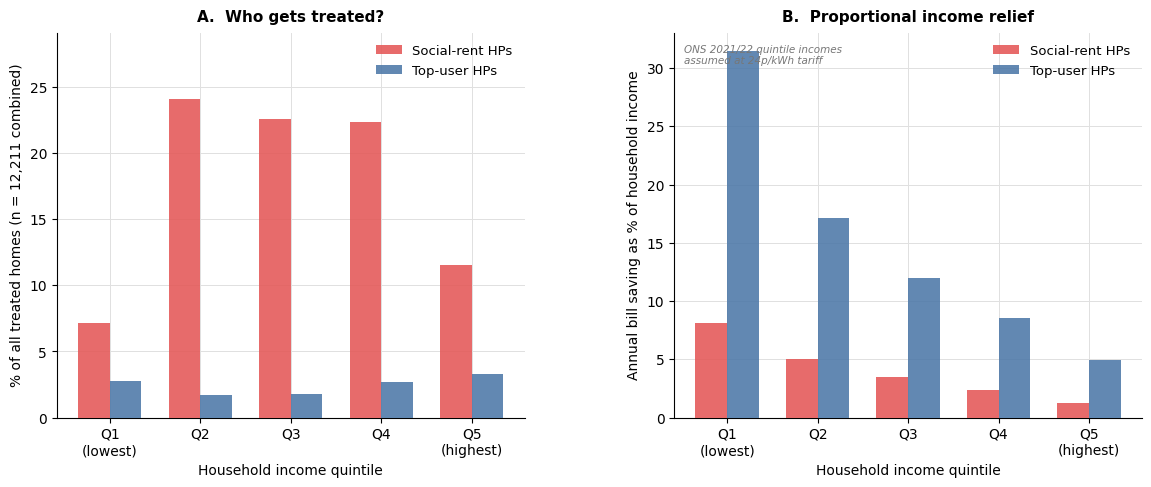

Figure 4 saved.


'      scenario income_band    n     share    mean_gbp  pct_income\nhp_social_rent   q1_lowest  871  7.132913  845.008017    8.125077\nhp_social_rent      q2_low 2946 24.125788  913.878359    5.021310\nhp_social_rent      q3_mid 2759 22.594382  956.591770    3.491211\nhp_social_rent     q4_high 2735 22.397838  944.135280    2.348595\nhp_social_rent  q5_highest 1411 11.555155  865.097403    1.218447\n  hp_top_users   q1_lowest  337  2.759807 3273.388247   31.474887\n  hp_top_users      q2_low  212  1.736140 3114.872512   17.114684\n  hp_top_users      q3_mid  213  1.744329 3273.834936   11.948303\n  hp_top_users     q4_high  328  2.686103 3424.744591    8.519265\n  hp_top_users  q5_highest  399  3.267546 3535.439421    4.979492'

In [20]:
# ── Figure 4. Who benefits? Income distribution of treated cohorts ─────────────
# Panel A: Share of ALL treated homes (combined pool) by income quintile
#          → bars across schemes are on the same denominator so the gap is visible
# Panel B: Mean annual bill saving as % of quintile household income
#          → proportional burden-reduction case
#          ONS 2021/22 net equivalised household income by quintile (£/year)

HP_SCENS = ['hp_social_rent', 'hp_top_users']
TARIFF   = 0.24

ONS_INCOME = {
    'q1_lowest':  10_400,
    'q2_low':     18_200,
    'q3_mid':     27_400,
    'q4_high':    40_200,
    'q5_highest': 71_000,
}

s_long = pd.read_csv(SCENARIO_LONG_CSV)
s_long = s_long[s_long['scenario'].isin(HP_SCENS)].copy()
s_long['delta_kwh_year'] = pd.to_numeric(s_long['delta_kwh_year'], errors='coerce').fillna(0.0)
s_long['saving_kwh'] = -s_long['delta_kwh_year']
s_long['saving_gbp'] = s_long['saving_kwh'] * TARIFF

if 'effective_adopter' in s_long.columns:
    active = s_long['effective_adopter'].fillna(False).astype(bool)
else:
    active = s_long['in_cohort'].fillna(False).astype(bool) & s_long['delta_kwh_year'].abs().gt(1e-9)

treated = s_long[active & s_long['saving_kwh'].gt(0)].copy()
treated['income_band'] = treated['hh_income_band'].fillna('missing').replace('', 'missing')

agg = (treated.groupby(['scenario', 'income_band'], as_index=False)
       .agg(n=('UPRN', 'nunique'), mean_gbp=('saving_gbp', 'mean')))

# Total treated across both schemes combined (denominator for Panel A)
total_all = int(agg[agg['income_band'].isin(QUINTILE_ORDER)]['n'].sum())

records = []
for scen in HP_SCENS:
    sub = agg[agg['scenario'] == scen].copy()
    for band in QUINTILE_ORDER:
        row = sub[sub['income_band'] == band]
        n_b   = int(row['n'].values[0]) if len(row) else 0
        gbp_b = float(row['mean_gbp'].values[0]) if len(row) else 0.0
        records.append({
            'scenario':    scen,
            'income_band': band,
            'n':           n_b,
            'share':       100 * n_b / total_all if total_all else 0,
            'mean_gbp':    gbp_b,
            'pct_income':  100 * gbp_b / ONS_INCOME[band],
        })
plot_q = pd.DataFrame(records)
plot_q['income_band'] = pd.Categorical(plot_q['income_band'], categories=QUINTILE_ORDER, ordered=True)
plot_q = plot_q.sort_values(['scenario', 'income_band'])

Q_LABELS = [QUINTILE_LABELS[b] for b in QUINTILE_ORDER]
x      = np.arange(len(QUINTILE_ORDER))
bar_w  = 0.35

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'wspace': 0.32})

# ── Panel A: % of all treated homes ──────────────────────────────────────────
for j, scen in enumerate(HP_SCENS):
    sub = plot_q[plot_q['scenario'] == scen].sort_values('income_band')
    offset = (j - 0.5) * bar_w
    ax_a.bar(x + offset, sub['share'], width=bar_w,
             color=SCENARIO_COLORS[scen], label=SCENARIO_LABELS[scen],
             alpha=0.88, zorder=3)

ax_a.set_xticks(x)
ax_a.set_xticklabels(Q_LABELS, fontsize=10)
ax_a.set_ylabel(f'% of all treated homes (n = {total_all:,} combined)', fontsize=10)
ax_a.set_title('A.  Who gets treated?', fontsize=11, fontweight='bold', pad=8)
ax_a.legend(frameon=False, fontsize=9.5, loc='upper right')
ax_a.set_ylim(0, ax_a.get_ylim()[1] * 1.15)
ax_a.set_xlabel('Household income quintile', fontsize=10)

# ── Panel B: saving as % of household income ─────────────────────────────────
for j, scen in enumerate(HP_SCENS):
    sub = plot_q[plot_q['scenario'] == scen].sort_values('income_band')
    offset = (j - 0.5) * bar_w
    ax_b.bar(x + offset, sub['pct_income'], width=bar_w,
             color=SCENARIO_COLORS[scen], label=SCENARIO_LABELS[scen],
             alpha=0.88, zorder=3)

ax_b.set_xticks(x)
ax_b.set_xticklabels(Q_LABELS, fontsize=10)
ax_b.set_ylabel('Annual bill saving as % of household income', fontsize=10)
ax_b.set_title('B.  Proportional income relief', fontsize=11, fontweight='bold', pad=8)
ax_b.legend(frameon=False, fontsize=9.5, loc='upper right')
ax_b.set_xlabel('Household income quintile', fontsize=10)
ax_b.text(0.02, 0.97, 'ONS 2021/22 quintile incomes\nassumed at 24p/kWh tariff',
          transform=ax_b.transAxes, va='top', fontsize=7.5,
          color='#777', style='italic')

fig.savefig(OUTDIR / 'figure_4_income_quintiles.png')
plt.show()
print('Figure 4 saved.')
display(plot_q[['scenario', 'income_band', 'n', 'share', 'mean_gbp', 'pct_income']].to_string(index=False))


## Figure 5. Spatial concentration of benefits

**Draft caption.**

*Figure 5. Spatial concentration of annual energy savings under two heat pump targeting strategies. The maps aggregate treated-dwelling savings to LSOA centroids for the top-user and social-rent scenarios using a common color scale. Savings under the top-user strategy are more spatially diffuse, reflecting the city-wide distribution of high-consuming dwellings. Savings under the social-rent strategy are more geographically concentrated, especially in areas with larger social housing clusters. This spatial concentration makes the programme easier to sequence and deliver through existing local authority and housing-provider structures.*


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_80952/1017450326.py:27: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  s_long = pd.read_csv(SCENARIO_LONG_CSV)


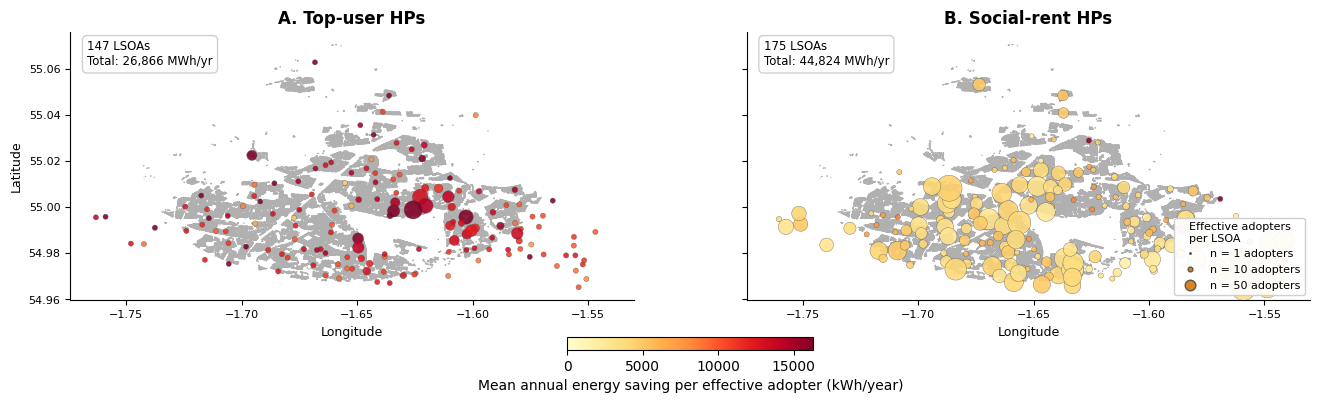

Figure 5 saved.


In [21]:
# ── Figure 5. Spatial concentration of benefits ───────────────────────────────
# Uses effective_adopter when present; falls back to non-zero treated deltas for old outputs.

import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

NCC_FULL = ROOT / 'data' / 'ncc_neighborhood_full.geojson'

ncc = gpd.read_file(NCC_FULL)
if ncc.crs is None:
    ncc = ncc.set_crs(4326)
ward_bounds = ncc[['ward_code', 'geometry']].dissolve(by='ward_code').reset_index()

with open(GEOJSON) as f:
    gj = json.load(f)

coord_rows = []
for feat in gj['features']:
    props = feat['properties']
    geom = feat['geometry']
    if geom and geom['type'] == 'Point':
        lon, lat = geom['coordinates']
        coord_rows.append((str(props.get('UPRN')), props.get('lsoa_code'), lon, lat))
coords = pd.DataFrame(coord_rows, columns=['UPRN', 'lsoa_code', 'lon', 'lat'])

s_long = pd.read_csv(SCENARIO_LONG_CSV)
KEEP = ['hp_top_users', 'hp_social_rent']
s_long = s_long[s_long['scenario'].isin(KEEP)].copy()
s_long['UPRN'] = s_long['UPRN'].astype(str)
s_long['delta_kwh_year'] = pd.to_numeric(s_long['delta_kwh_year'], errors='coerce').fillna(0.0)
s_long['saving_kwh'] = -s_long['delta_kwh_year']

if 'effective_adopter' in s_long.columns:
    active = s_long['effective_adopter'].fillna(False).astype(bool)
else:
    active = s_long['in_cohort'].fillna(False).astype(bool) & s_long['delta_kwh_year'].abs().gt(1e-9)

map_df = s_long[active & s_long['saving_kwh'].gt(0)].copy()
map_df = map_df.merge(coords, on='UPRN', how='left')

agg = (map_df.groupby(['scenario', 'lsoa_code'], as_index=False)
       .agg(mean_saving_kwh=('saving_kwh', 'mean'),
            total_saving_kwh=('saving_kwh', 'sum'),
            n_treated=('UPRN', 'size'),
            lon=('lon', 'mean'),
            lat=('lat', 'mean')))

vmax = float(np.nanpercentile(agg['mean_saving_kwh'].dropna(), 95))
vmin = 0.0
CMAP = 'YlOrRd'
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
MAX_S = 350
n_ref = max(agg['n_treated'].max(), 1)
PANEL_TITLES = {'hp_top_users': 'A. Top-user HPs', 'hp_social_rent': 'B. Social-rent HPs'}

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True, sharex=True)
for ax, scen in zip(axes, KEEP):
    sub = agg[agg['scenario'] == scen].dropna(subset=['lon', 'lat', 'mean_saving_kwh'])
    ward_bounds.plot(ax=ax, color='#f5f5f5', edgecolor='#b0b0b0', linewidth=0.8, zorder=1)
    s_px = MAX_S * np.clip(sub['n_treated'] / n_ref, 0.04, 1.0)
    ax.scatter(sub['lon'], sub['lat'], c=sub['mean_saving_kwh'], cmap=CMAP, norm=norm,
               s=s_px, alpha=0.88, edgecolors='#444', linewidths=0.25, zorder=3)
    ax.set_title(PANEL_TITLES[scen], fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_aspect('equal')
    ax.grid(alpha=0.0)
    n_lsoa = len(sub)
    tot_mwh = float(sub['total_saving_kwh'].sum() / 1e3)
    ax.text(0.03, 0.97, f'{n_lsoa} LSOAs\nTotal: {tot_mwh:,.0f} MWh/yr',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#ccc', alpha=0.92), zorder=4)

axes[0].set_ylabel('Latitude', fontsize=9)
axes[1].tick_params(labelleft=False)
ref_ns = [1, 10, 50]
ref_ns = [n for n in ref_ns if n <= n_ref]
size_lgnd = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e08020', markeredgecolor='#555',
           markersize=np.sqrt(MAX_S * n / n_ref), label=f'n = {n} adopters')
    for n in ref_ns
]
axes[1].legend(handles=size_lgnd, title='Effective adopters\nper LSOA',
               loc='lower right', fontsize=8, title_fontsize=8, framealpha=0.92)
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal', fraction=0.02, pad=0.06, shrink=0.45)
cbar.set_label('Mean annual energy saving per effective adopter (kWh/year)', fontsize=10)

fig.savefig(OUTDIR / 'figure_5_spatial.png')
plt.show()
print('Figure 5 saved.')


## Output files

Running this notebook writes the current figure set to:

`notebooks/results/too_hot_to_handle_figures/`

Current filenames:

- `figure_1_pipeline.png`
- `figure_2_validation.png`
- `figure_3_tradeoffs.png`
- `figure_4_income_quintiles.png`
- `figure_5_spatial.png`
